# Model 2: DAE implementation

## Problem Statement

This part is meant to rewrite the system of equations we already know and love as model 2 (and which we h_gave also solved using our own IMEX Method), as a DAE, and solve it with an automatic solver. The goal is to solve for:

\begin{equation}
\left\{\begin{aligned}
    \partial_t\rho_g&= D(\Delta\rho_g)-\mathbf{v}\cdot(\nabla\rho_g)-\dot m_a(\rho_g, \rho_s) \\
    \partial_t\rho_s&=\dot m_a(\rho_g, \rho_s)
\end{aligned}\right.
\end{equation}
Where $\rho$ is the density at that point and $\rho_s$ is the saturation of the metal. $D$ is the diffusivity, and $\mathbf{v}$ the velocity ($\mathbf v=(v_x, v_y)$).

### Mathematical Discretizations

Under initial condition and boundary conditions are (since there is no coupling effects of saturation of the metal I am pretty sure we do not need boundary conditions there, but I'll look into this and phrase it more rigorous):

\begin{equation}
\left\{ \begin{aligned}
    \rho_g(\mathbf{x}, 0)  &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_s(\mathbf{x},0) &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_g(\mathbf{x}, t)  &= 1, &\forall \mathbf{x}\in\partial\Omega_1,\forall t\geq 0, \\
    \partial_\mathbf{n}\rho_g(\mathbf{x}, t)  &= 0, &\forall \mathbf{x}\in\partial\Omega_2,\forall t\geq 0. 
\end{aligned}\right.
\end{equation}

where $\mathbf x = (x, y)$. the function for calculating adsorption is simplified into:

$$
\dot m(\rho_g, \rho_s) = M_a\log \left(\frac{RT\rho_g}{p_{eqa}}\right)(\rho_{sat}-\rho_s)
$$

We will be expanding $\rho_g^n$, and $\rho_s^n$, (the values at their respective timesteps) into Lagrange polynomials:

\begin{equation*}
\begin{aligned}
\rho_g^n&=\sum{\rho_g^{n,i}\psi^i},\\
\rho_s^n&=\sum{\rho_s^{n,i}\psi^i}.
\end{aligned}
\end{equation*}

we want to solve for $\rho_g$ and $\rho_s$, so our solution vector $\mathbf{u^n}$ becomes:

$$
\mathbf{u^n} = \begin{pmatrix}\rho_g^{n, 1} \\ \vdots \\ \rho_g^{n, N} \\ \rho_s^{n, 1} \\ \vdots \\ \rho_s^{n, N}
\end{pmatrix}
$$

if we discretize, we get:

$$
M\dot{\mathbf{u}}=\begin{pmatrix}D-C & 0 \\ 0 & 0\end{pmatrix}\mathbf{u}+\begin{pmatrix}-\dot m_a(\rho_g, \rho_s) \\ \dot m_a(\rho_g, \rho_s)\end{pmatrix}
$$

which simply becomes:

$$
res(\mathbf{u}, \mathbf{du}) = M{\mathbf{du}}-L\mathbf{u}-\mathbf{f}(\mathbf{u})
$$

Where we have again:

$$
L = \begin{pmatrix}D-C & 0 \\ 0 & 0\end{pmatrix}, \\ \mathbf{f}(\mathbf{u}) = \begin{pmatrix}-\dot m_a(\rho_g, \rho_s) \\ \dot m_a(\rho_g, \rho_s)\end{pmatrix},\\
M_{ij}=\int \psi^i\psi^j dx,\\
C_{ij}=\int (\mathbf{v}\cdot\nabla\psi^i)\psi^j \,dx,\\
D_{ij}=\int (\nabla \cdot \psi^i)(\nabla \cdot \psi^j)\, dx$$

In [1]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra, DifferentialEquations

In [2]:
include(joinpath(@__DIR__, "FEMDAESolver.jl"))
using .FEMDAESolver

In [3]:
# constants
R = 8.314           # J/(mol*K)     
T = 300.0           # K
μ = 8.4e-6          # Pa*s = kg/(m*s)
C_a = 59.187        # s^-1
p_ref = 1.0e6       # 1MPA
ρ_sat = 7259.0      # kg/m^3
ρ_e = 7165.0        # kg/m^3
E_a = 21179.6       # J/mol
ϵ = 0.4             # unitless, measure of porosity
A_hoffman = 10.7    # unitless
B_hoffman = 3704.6  # K

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = C_a * exp(-E_a/(R*T))
p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

ρ_in = 4.0 * p_eqa / (R * T)

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 0.012144991086083792 s^-1
p_eqa = 192306.14595250844 Pa


In [4]:
cm2 = Constants_Model2(
    R,        # R::Float64
    T,        # T::Float64
    μ,        # μ::Float64
    1.0,        # velocity::Float64
    ϵ,        # ϵ::Float64
    A_a,        # MA::Float64
    ρ_sat,        # rho_sat::Float64
    p_eqa,        # p_eqa::Float64
    ρ_e        # ρ_e::Float64
)

folder_name = "c. dae"

"c. dae"

## Definitions

## grid

In [5]:
# generates grid
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho_g, rho_s
ip_rho_g = Lagrange{RefLine, 1}()
cellvalues_rho_g = CellValues(qr, ip_rho_g);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [6]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :rho_g, ip_rho_g)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [7]:
# constraint handler
ch = ConstraintHandler(dh)
    
inlet_ρ = Dirichlet(
    :rho_g,
    left,
    (x, t) -> ρ_in
)
    
# add the constraints to the constraint handler
# ρ_s is not constrained, since it is not coupled spacially yay
add!(ch, inlet_ρ)

close!(ch)
update!(ch, 0.0)

In [8]:
# for debugging purpuses

const rho_g_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_g)]
    for cell in CellIterator(dh)
]...)))

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

In [9]:
# Pes = [100, 200, 500, 1000, 5000, 20000, 100000]
# oscillations = zeros(length(Pes))

# for (i, Pe) in enumerate(Pes)

#     μ = 1.0 * 0.01 / Pe   # since velocity = 1, h=0.01
#     cm2 = Constants_Model2(
#         1.0,        # R::Float64
#         1.0,        # T::Float64
#         1.0,        # A::Float64
#         μ,          # μ::Float64
#         1.0,        # velocity::Float64
#         0.4,        # ϵ::Float64
#         1.0,        # MA::Float64
#         1.0,        # rho_sat::Float64
#         1.0,        # p_eqa::Float64
#         1.0         # K::Float64    
#     )

#     sol = solve_fem_absorption(
#         cellvalues_rho_g,
#         cellvalues_rho_s,
#         ch,
#         dh,
#         cm2,
#         1.0
#     )

#     u = sol.u[end]

#     oscillations[i] = max(
#         maximum(u) - 2.0,
#         -minimum(u),
#         0.0
#     )

#     println("Pe = $(Pe), μ = $(μ), oscillation = $(oscillations[i])")
# end

In [34]:
# cm2 = Constants_Model2(
#     1.0,        # R::Float64
#     1.0,        # T::Float64
#     1.0,        # A::Float64
#     0.000000001,        # μ::Float64
#     0.5,        # velocity::Float64
#     0.4,        # ϵ::Float64
#     1.0,        # MA::Float64
#     1.0,        # rho_sat::Float64
#     1.0,        # p_eqa::Float64
#     1.0         # K::Float64    
# )

sol = solve_fem_absorption(
    cellvalues_rho_g,
    cellvalues_rho_s,
    ch,
    dh,
    cm2,
    250.0,
    0.1
);

In [20]:
sol.alg

Sundials.IDA{:Dense, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

## Plotting/animating

In [11]:
using Plots

In [35]:
U = Array(sol);

In [36]:
# double gif plot
foldername = "c. dae"

U = Array(sol)

# sol_v = U[v_global, :]
sol_ρ = U[rho_g_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

ρsmax = maximum(sol_ρ_s)
ρsmin = minimum(sol_ρ_s)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=4))",
        ylims=(0, ρmax),
        legend=:topright
    )

    p2 = plot(
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
        ylims=(ρsmin, ρsmax),
    )

    plot(p1, p2, layout=(2,1), size=(600,300))
end;

[ Info: Saved animation to c:\Users\noudh\uni\MEP\Model 2\c. dae\D.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\Model 2\\c. dae\\D.gif")
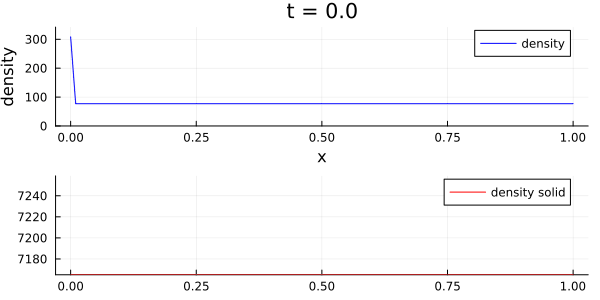

In [41]:
gif(anim, joinpath(foldername, "D.gif"), fps=50)

In [17]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = M[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

LoadError: UndefVarError: `M` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [38]:
fill_fraction = [sum(sol_ρ_s[:,k]) for k in 1:size(sol_ρ_s, 2)]./size(sol_ρ_s, 1)

2501-element Vector{Float64}:
 7165.0
 7165.035455013565
 7165.136037714487
 7165.301472118604
 7165.53149160537
 7165.792904901192
 7166.0535999815265
 7166.313571342919
 7166.572816598366
 7166.831338529295
 7167.089142264686
 7167.346224103825
 7167.60258776194
    ⋮
 7258.910962565142
 7258.9112064380515
 7258.911449618664
 7258.9116921094765
 7258.911934116695
 7258.912177554303
 7258.9124203607735
 7258.912662539215
 7258.912904092741
 7258.913145024473
 7258.913385337533
 7258.913625035052

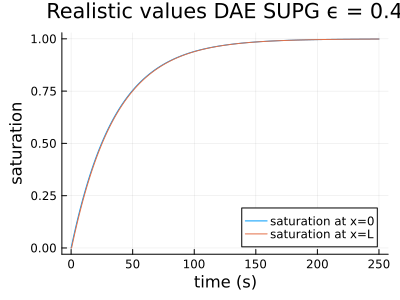

In [54]:
plot(
    sol.t,
    (sol_ρ_s[1, :] .- ρ_e) ./ (ρ_sat - ρ_e),
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    title = "Realistic values DAE SUPG ϵ = $(ϵ)",
    legend=:bottomright,
    size=(400,300)
)
k = log(2)/(1-ϵ)
# plot!(
#     sol.t,
#     1.0 .- 1 .* exp.(-k.*sol.t),
#     label = "analytical solution at x=0",
#     linestyle = :dash
# )

# plot!(
#     sol.t,
#     fill_fraction/(1-ϵ),
#     # xlabel = "time",
#     # ylabel = "fraction filled",
#     label = "full solid saturation"
#     )

plot!(
    sol.t,
    (sol_ρ_s[end, :] .- ρ_e) ./ (ρ_sat - ρ_e),
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)

# plot!(
#     [sol.t[1], sol.t[end]],
#     [ρ_sat, ρ_sat],
#     # xlabel = "time",
#     # ylabel = "solid density [kg/m^3]",
#     label = "saturation limit"
# )

# plot!(
#     sol.t,
#     fill_fraction,
#     # xlabel = "time",
#     # ylabel = "fraction filled",
#     label = "average solid saturation"
# )

In [55]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_2_result_realistic_DAE_SUPG.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_2_result_realistic_DAE_SUPG.png"

In [196]:
display(anim)

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_eEKXHW", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000072.png", "000073.png", "000074.png", "000075.png", "000076.png", "000077.png", "000078.png", "000079.png", "000080.png", "000081.png"])

In [225]:
savefig(joinpath(foldername, "fill_fraction.png"))

"c:\\Users\\noudh\\uni\\MEP\\Model 2\\c. dae\\fill_fraction.png"